In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
# make sure pandas is version 1.0 or higher
# make sure networkx is verion 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.2
3.4.2


In [3]:
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time



In [4]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(3)

In [5]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)

CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [6]:
# enlisting policy levers, their types (RealParameter/IntegerParameter), lower boundary, and upper boundary
for policy in dike_model.levers:
    print(repr(policy))

levers = copy.deepcopy(dike_model.levers)

IntegerParameter('0_RfR 0', 0, 1, resolution=None, default=None, variable_name=['0_RfR 0'], pff=False)
IntegerParameter('0_RfR 1', 0, 1, resolution=None, default=None, variable_name=['0_RfR 1'], pff=False)
IntegerParameter('0_RfR 2', 0, 1, resolution=None, default=None, variable_name=['0_RfR 2'], pff=False)
IntegerParameter('1_RfR 0', 0, 1, resolution=None, default=None, variable_name=['1_RfR 0'], pff=False)
IntegerParameter('1_RfR 1', 0, 1, resolution=None, default=None, variable_name=['1_RfR 1'], pff=False)
IntegerParameter('1_RfR 2', 0, 1, resolution=None, default=None, variable_name=['1_RfR 2'], pff=False)
IntegerParameter('2_RfR 0', 0, 1, resolution=None, default=None, variable_name=['2_RfR 0'], pff=False)
IntegerParameter('2_RfR 1', 0, 1, resolution=None, default=None, variable_name=['2_RfR 1'], pff=False)
IntegerParameter('2_RfR 2', 0, 1, resolution=None, default=None, variable_name=['2_RfR 2'], pff=False)
IntegerParameter('3_RfR 0', 0, 1, resolution=None, default=None, variable

In [7]:
# enlisting outcomes
for outcome in dike_model.outcomes:
    print(repr(outcome))

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x000002CA381C7E20>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Dama

In [8]:
# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=50, policies=4)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 50 scenarios * 4 policies * 1 model(s) = 200 experiments
100%|████████████████████████████████████████| 200/200 [00:48<00:00,  4.15it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [9]:
# observing the simulation runs
experiments, outcomes = results
print(outcomes.keys())
experiments

dict_keys(['A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs'])


,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,EWS_DaysToThreat,scenario,policy,model
0,23,137.319132,1.0,0.656057,325.003459,1.5,0.409173,262.197352,1.0,0.784431,...,1,3,10,4,3,10,2,4,0,dikesnet
1,103,86.730147,10.0,0.955561,238.153353,1.5,0.103015,304.544956,1.5,0.614214,...,1,3,10,4,3,10,2,5,0,dikesnet
2,33,104.463159,1.5,0.828578,105.323322,10.0,0.075491,64.113469,1.5,0.768748,...,1,3,10,4,3,10,2,6,0,dikesnet
3,85,286.735486,10.0,0.254415,171.734792,1.0,0.997714,204.758866,10.0,0.654640,...,1,3,10,4,3,10,2,7,0,dikesnet
4,88,71.454211,10.0,0.895137,250.102464,10.0,0.775749,41.186583,1.0,0.014246,...,1,3,10,4,3,10,2,8,0,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,40,166.333857,1.0,0.660000,278.732192,1.0,0.671887,344.546879,10.0,0.408699,...,6,9,3,0,10,0,4,49,3,dikesnet
196,90,239.241580,10.0,0.137207,195.994841,1.0,0.564225,250.347713,1.5,0.535579,...,6,9,3,0,10,0,4,50,3,dikesnet
197,118,280.983818,1.5,0.324889,132.631309,10.0,0.913182,342.435319,1.5,0.922790,...,6,9,3,0,10,0,4,51,3,dikesnet
198,16,346.469302,1.5,0.059168,211.368327,10.0,0.654591,220.279564,10.0,0.582393,...,6,9,3,0,10,0,4,52,3,dikesnet


In [10]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1.262484e+08,0.0,2.106307e+08,0.000408,6.072173e+07,0.006136,4.404415e+07,0.000320,1.416976e+08,0.000000,9.299000e+08,1150.330948
1,1.262484e+08,0.0,2.226597e+08,0.003286,7.109310e+07,0.008907,3.837970e+07,0.000000,1.416976e+08,0.000000,9.299000e+08,2207.889580
2,1.262484e+08,0.0,2.676623e+08,0.008104,4.345218e+07,0.003090,3.837970e+07,0.000000,1.416976e+08,0.000000,9.299000e+08,3010.660591
3,1.262484e+08,0.0,2.069759e+08,0.000000,5.250759e+07,0.006076,3.858370e+07,0.000020,1.416976e+08,0.000000,9.299000e+08,802.900949
4,1.262484e+08,0.0,2.069759e+08,0.000000,1.114224e+09,0.321081,4.373114e+07,0.000435,1.416976e+08,0.000000,9.299000e+08,54904.587768
...,...,...,...,...,...,...,...,...,...,...,...,...
195,2.589783e+08,0.0,2.463423e+08,0.000000,1.327229e+08,0.000000,4.877635e+07,0.000000,1.158648e+08,0.005959,1.305500e+09,4288.564664
196,2.589783e+08,0.0,2.463423e+08,0.000000,1.327229e+08,0.000000,4.877635e+07,0.000000,1.610025e+08,0.008063,1.305500e+09,6022.199063
197,2.589783e+08,0.0,2.463423e+08,0.000000,1.327229e+08,0.000000,4.877635e+07,0.000000,8.030333e+07,0.003563,1.305500e+09,2460.075808
198,2.589783e+08,0.0,2.463423e+08,0.000000,1.327229e+08,0.000000,4.877635e+07,0.000000,6.096419e+07,0.000462,1.305500e+09,302.081421


In [11]:
# defining specific policies
# for example, policy 1 is about extra protection in upper boundary
# policy 2 is about extra protection in lower boundary
# policy 3 is extra protection in random locations


def get_do_nothing_dict():
    return {l.name: 0 for l in dike_model.levers}


policies = [
    Policy(
        "policy 1",
        **dict(
            get_do_nothing_dict(),
            **{"0_RfR 0": 1, "0_RfR 1": 1, "0_RfR 2": 1, "A.1_DikeIncrease 0": 5}
        )
    ),
    Policy(
        "policy 2",
        **dict(
            get_do_nothing_dict(),
            **{"4_RfR 0": 1, "4_RfR 1": 1, "4_RfR 2": 1, "A.5_DikeIncrease 0": 5}
        )
    ),
    Policy(
        "policy 3",
        **dict(
            get_do_nothing_dict(),
            **{"1_RfR 0": 1, "2_RfR 1": 1, "3_RfR 2": 1, "A.3_DikeIncrease 0": 5}
        )
    ),
]

In [12]:
# pass the policies list to EMA workbench experiment runs
n_scenarios = 100
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios, policies)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 100 scenarios * 3 policies * 1 model(s) = 300 experiments
100%|████████████████████████████████████████| 300/300 [01:11<00:00,  4.19it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [13]:
experiments, outcomes = results

In [14]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,5.397251e+07,0.000000,2.917483e+08,0.298203,1.364469e+09,2.605751,0.000000e+00,0.000000,0.000000e+00,0.000000,253800000.0,0.0
1,5.397251e+07,0.000000,7.442532e+08,0.651975,2.001673e+09,3.323401,5.315842e+07,0.017367,0.000000e+00,0.000000,253800000.0,0.0
2,5.397251e+07,0.000000,5.360604e+08,0.419963,0.000000e+00,0.000000,4.014120e+06,0.001595,1.241395e+08,0.095023,253800000.0,0.0
3,5.397251e+07,0.000000,3.432939e+08,0.292086,0.000000e+00,0.000000,1.107352e+08,0.044740,0.000000e+00,0.000000,253800000.0,0.0
4,5.397251e+07,0.000000,7.785815e+08,0.862014,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,253800000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
295,4.773926e+07,0.026966,5.895678e+06,0.004922,3.049024e+07,0.002630,1.473578e+07,0.006350,7.670348e+08,0.556420,369700000.0,0.0
296,8.360720e+08,0.732492,0.000000e+00,0.000000,2.879840e+07,0.000000,2.355660e+06,0.001454,0.000000e+00,0.000000,369700000.0,0.0
297,4.987753e+07,0.029479,5.569648e+08,0.427129,2.879840e+07,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,369700000.0,0.0
298,0.000000e+00,0.000000,1.946542e+08,0.159120,2.879840e+07,0.000000,7.651367e+07,0.030603,0.000000e+00,0.000000,369700000.0,0.0


### Step 2 - Open Exploration

In [15]:
# Choose Problem Formulation
dike_model, planning_steps = get_model_for_problem_formulation(2)
print([o.name for o in dike_model.outcomes])

['Expected Annual Damage', 'Dike Investment Costs', 'RfR Investment Costs', 'Evacuation Costs', 'Expected Number of Deaths']


In [18]:
print("🔍 Uncertainties (eerste 10 [:10] ):")
for u in list(dike_model.uncertainties):
    print(f" - {u.name}")

print("\n🎛 Levers:")
for l in list(dike_model.levers):
    print(f" - {l.name}")

print("\n🎯 Outcomes:")
for o in dike_model.outcomes:
    print(f" - {o.name}")

🔍 Uncertainties (eerste 10 [:10] ):
 - discount rate 0
 - discount rate 1
 - discount rate 2
 - A.0_ID flood wave shape
 - A.1_Bmax
 - A.1_pfail
 - A.1_Brate
 - A.2_Bmax
 - A.2_pfail
 - A.2_Brate
 - A.3_Bmax
 - A.3_pfail
 - A.3_Brate
 - A.4_Bmax
 - A.4_pfail
 - A.4_Brate
 - A.5_Bmax
 - A.5_pfail
 - A.5_Brate

🎛 Levers:
 - 0_RfR 0
 - 0_RfR 1
 - 0_RfR 2
 - 1_RfR 0
 - 1_RfR 1
 - 1_RfR 2
 - 2_RfR 0
 - 2_RfR 1
 - 2_RfR 2
 - 3_RfR 0
 - 3_RfR 1
 - 3_RfR 2
 - 4_RfR 0
 - 4_RfR 1
 - 4_RfR 2
 - EWS_DaysToThreat
 - A.1_DikeIncrease 0
 - A.1_DikeIncrease 1
 - A.1_DikeIncrease 2
 - A.2_DikeIncrease 0
 - A.2_DikeIncrease 1
 - A.2_DikeIncrease 2
 - A.3_DikeIncrease 0
 - A.3_DikeIncrease 1
 - A.3_DikeIncrease 2
 - A.4_DikeIncrease 0
 - A.4_DikeIncrease 1
 - A.4_DikeIncrease 2
 - A.5_DikeIncrease 0
 - A.5_DikeIncrease 1
 - A.5_DikeIncrease 2

🎯 Outcomes:
 - Expected Annual Damage
 - Dike Investment Costs
 - RfR Investment Costs
 - Evacuation Costs
 - Expected Number of Deaths


In [ ]:
from ema_workbench import Scenario, Policy

# Stap 1: Scenario maken (vaste waarden voor uncertainties)
ref_values = {
    "Bmax": 175,
    "Brate": 1.5,
    "pfail": 0.5,
    "ID flood wave shape": 4,
}
ref_values.update({f"discount rate {n}": 3.5 for n in planning_steps})

# Koppel scenario-waarden aan alle uncertainties
scen = {}
for unc in dike_model.uncertainties:
    parts = unc.name.split("_")
    key = unc.name
    value = ref_values.get(parts[-1], 0)
    scen[key] = value

reference_scenario = Scenario("Reference", **scen)

# Stap 2: Beleidsoptie maken — een "zero policy" (geen maatregelen)
zero_policy = {}
for lever in dike_model.levers:
    name = lever.name
    if "DikeIncrease" in name or "RfR" in name:
        zero_policy[name] = 0
    elif "DaysToThreat" in name:
        zero_policy[name] = 0
    else:
        zero_policy[name] = 0

policy0 = Policy("Zero Policy", **zero_policy)

In [21]:
print("🎲 Reference Scenario – Uncertainty values:")
for k, v in reference_scenario.items():
    print(f" - {k}: {v}")


🎲 Reference Scenario – Uncertainty values:
 - discount rate 0: 3.5
 - discount rate 1: 3.5
 - discount rate 2: 3.5
 - A.0_ID flood wave shape: 4
 - A.1_Bmax: 175
 - A.1_pfail: 0.5
 - A.1_Brate: 1.5
 - A.2_Bmax: 175
 - A.2_pfail: 0.5
 - A.2_Brate: 1.5
 - A.3_Bmax: 175
 - A.3_pfail: 0.5
 - A.3_Brate: 1.5
 - A.4_Bmax: 175
 - A.4_pfail: 0.5
 - A.4_Brate: 1.5
 - A.5_Bmax: 175
 - A.5_pfail: 0.5
 - A.5_Brate: 1.5


In [22]:
from ema_workbench import perform_experiments

# Simuleer 1 experiment met het scenario + policy
experiments, outcomes = perform_experiments(
    models=dike_model,
    scenarios=[reference_scenario],
    policies=[policy0]
)

[MainProcess/INFO] performing 1 scenarios * 1 policies * 1 model(s) = 1 experiments
100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  1.86it/s]
[MainProcess/INFO] experiments finished


,Zero Policy – Reference Scenario
Expected Annual Damage,2.974628e+08
Dike Investment Costs,0.000000e+00
RfR Investment Costs,0.000000e+00
Evacuation Costs,0.000000e+00
Expected Number of Deaths,3.856464e-01


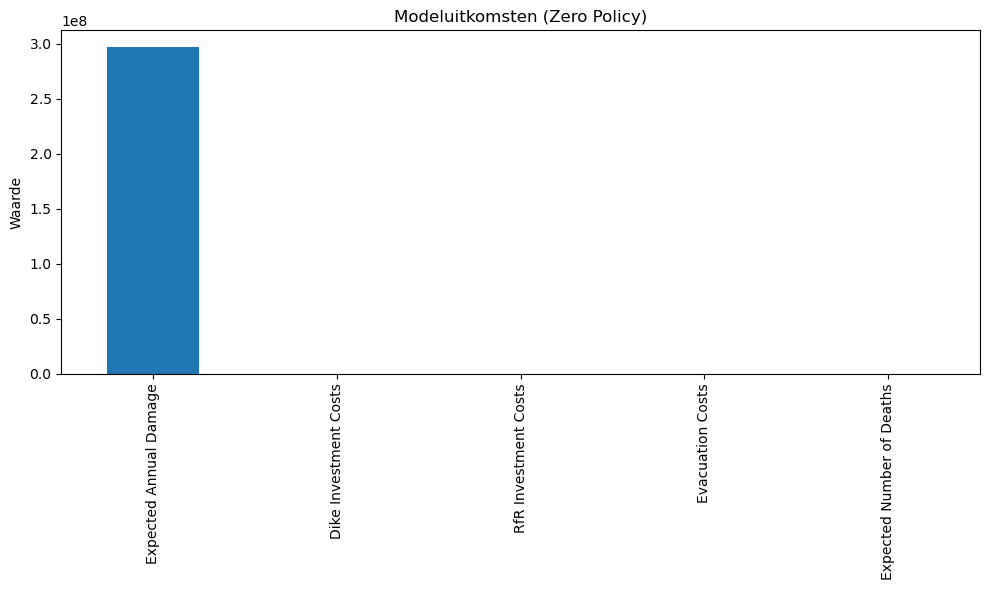

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Zet de dictionary om in een dataframe
df_out = pd.DataFrame(outcomes)

# Transponeer en toon als tabel
df_out_T = df_out.T
df_out_T.columns = ["Zero Policy – Reference Scenario"]
display(df_out_T)

# Plot als staafdiagram
df_out_T.plot(kind='bar', legend=False, figsize=(10, 6))
plt.title("Modeluitkomsten (Zero Policy)")
plt.ylabel("Waarde")
plt.tight_layout()
plt.show()


In [24]:
from ema_workbench import Policy

# Policy 0: geen maatregelen
policy0 = Policy("No Policy", **{lev.name: 0 for lev in dike_model.levers})

# Policy 1: alle dijken verhogen met 5 (halve meter)
policy1_settings = {}
for lev in dike_model.levers:
    if "DikeIncrease" in lev.name:
        policy1_settings[lev.name] = 5
    elif "RfR" in lev.name:
        policy1_settings[lev.name] = 0
    elif "DaysToThreat" in lev.name:
        policy1_settings[lev.name] = 0
policy1 = Policy("Dike +0.5m", **policy1_settings)

# Policy 2: alle RfR aan + waarschuwing op max
policy2_settings = {}
for lev in dike_model.levers:
    if "DikeIncrease" in lev.name:
        policy2_settings[lev.name] = 0
    elif "RfR" in lev.name:
        policy2_settings[lev.name] = 1
    elif "DaysToThreat" in lev.name:
        policy2_settings[lev.name] = 4
policy2 = Policy("RfR + Warning", **policy2_settings)

policies = [policy0, policy1, policy2]

In [25]:
experiments, outcomes = perform_experiments(
    models=dike_model,
    scenarios=[reference_scenario],  # steeds dezelfde onzekerheden
    policies=policies                # drie verschillende beleidsopties
)


[MainProcess/INFO] performing 1 scenarios * 3 policies * 1 model(s) = 3 experiments
100%|████████████████████████████████████████████| 3/3 [00:01<00:00,  1.92it/s]
[MainProcess/INFO] experiments finished


,No Policy,Dike +0.5m,RfR + Warning
Expected Annual Damage,2.974628e+08,0.0,1.305214e+07
Dike Investment Costs,0.000000e+00,680368907.0,0.000000e+00
RfR Investment Costs,0.000000e+00,0.0,2.131200e+09
Evacuation Costs,0.000000e+00,0.0,1.016056e+03
Expected Number of Deaths,3.856464e-01,0.0,1.779546e-03


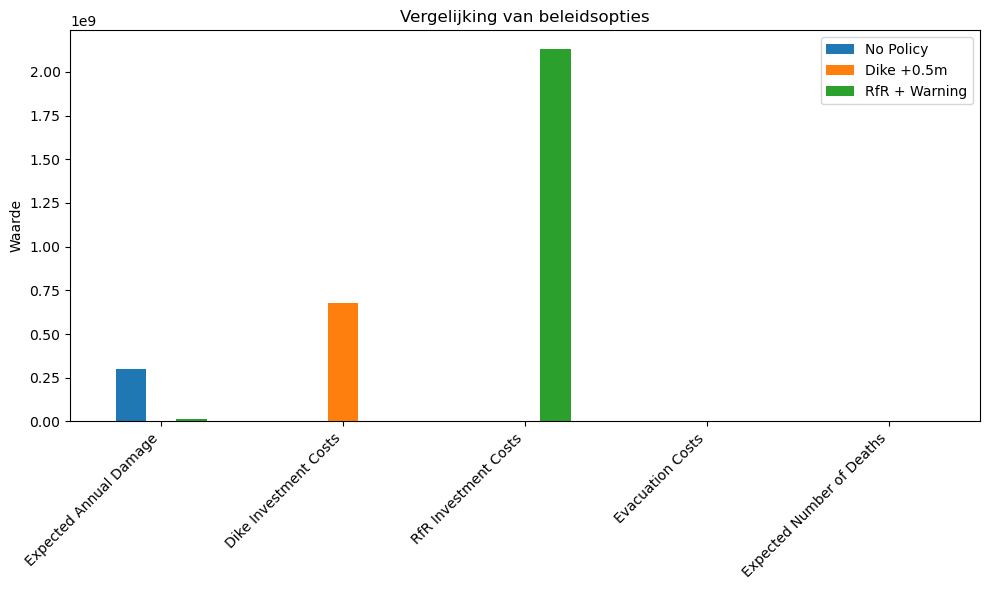

In [26]:
# Zet outcomes om naar DataFrame
df_out = pd.DataFrame(outcomes)

# Transponeer om rijen = uitkomsten, kolommen = policies
df_out_T = df_out.T
df_out_T.columns = [p.name for p in policies]

# Toon als tabel
display(df_out_T)

# Plot als staafdiagram
df_out_T.plot(kind='bar', figsize=(10, 6))
plt.title("Vergelijking van beleidsopties")
plt.ylabel("Waarde")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [27]:
# Mild dijkbeleid + waarschuwing
policy3_settings = {}
for lev in dike_model.levers:
    if "DikeIncrease" in lev.name:
        policy3_settings[lev.name] = 2  # 20 cm
    elif "RfR" in lev.name:
        policy3_settings[lev.name] = 0
    elif "DaysToThreat" in lev.name:
        policy3_settings[lev.name] = 2
policy3 = Policy("Mild Dike + Warn", **policy3_settings)

# Alleen RfR 0-2 actief
policy4_settings = {}
for lev in dike_model.levers:
    if "DikeIncrease" in lev.name:
        policy4_settings[lev.name] = 0
    elif "RfR" in lev.name:
        if lev.name.startswith(("0_", "1_", "2_")):
            policy4_settings[lev.name] = 1
        else:
            policy4_settings[lev.name] = 0
    elif "DaysToThreat" in lev.name:
        policy4_settings[lev.name] = 0
policy4 = Policy("Half RfR", **policy4_settings)

# Combi: lichte dijkverhoging + lichte RfR
policy5_settings = {}
for lev in dike_model.levers:
    if "DikeIncrease" in lev.name:
        policy5_settings[lev.name] = 1  # 10 cm
    elif "RfR" in lev.name:
        policy5_settings[lev.name] = 1 if lev.name.startswith("0_") else 0
    elif "DaysToThreat" in lev.name:
        policy5_settings[lev.name] = 1
policy5 = Policy("Light Combo", **policy5_settings)

# Voeg toe aan je lijst
policies = [policy0, policy1, policy2, policy3, policy4, policy5]

In [28]:
experiments, outcomes = perform_experiments(
    models=dike_model,
    scenarios=[reference_scenario],
    policies=policies
)

[MainProcess/INFO] performing 1 scenarios * 6 policies * 1 model(s) = 6 experiments
100%|████████████████████████████████████████████| 6/6 [00:03<00:00,  1.79it/s]
[MainProcess/INFO] experiments finished


,No Policy,Dike +0.5m,RfR + Warning,Mild Dike + Warn,Half RfR,Light Combo
Expected Annual Damage,2.974628e+08,0.0,1.305214e+07,1.545691e+07,1.085569e+08,5.875549e+07
Dike Investment Costs,0.000000e+00,680368907.0,0.000000e+00,4.407179e+08,0.000000e+00,3.805029e+08
RfR Investment Costs,0.000000e+00,0.0,2.131200e+09,0.000000e+00,9.993000e+08,2.538000e+08
Evacuation Costs,0.000000e+00,0.0,1.016056e+03,7.464580e+02,0.000000e+00,1.825398e+03
Expected Number of Deaths,3.856464e-01,0.0,1.779546e-03,4.093787e-03,1.220779e-01,3.390111e-02


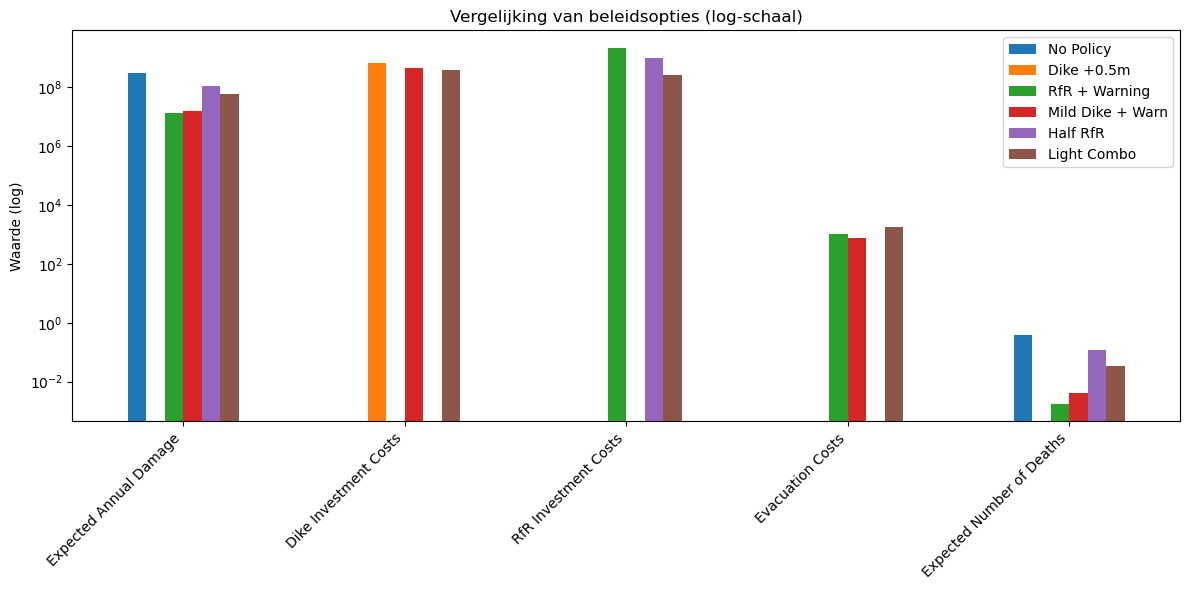

In [29]:
# Zet outcomes om naar DataFrame
df_out = pd.DataFrame(outcomes)

# Transponeer: rijen = uitkomsten, kolommen = policies
df_out_T = df_out.T
df_out_T.columns = [p.name for p in policies]

# Toon tabel
display(df_out_T)

# Plot (met log-schaal voor beter vergelijk)
df_out_T.plot(kind='bar', figsize=(12, 6), logy=True)
plt.title("Vergelijking van beleidsopties (log-schaal)")
plt.ylabel("Waarde (log)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
from ema_workbench import perform_experiments, Samplers

n_exp = 10  # of 500/1000 voor grotere runs

results_lhs = perform_experiments(
    models=dike_model,
    scenarios=n_exp,
    policies=policies,  # jouw lijst met policy0 t/m policy5
    uncertainty_sampling=Samplers.LHS
)

experiments, outcomes = results_lhs


[MainProcess/INFO] performing 10 scenarios * 6 policies * 1 model(s) = 60 experiments
  0%|                                                   | 0/60 [00:00<?, ?it/s][MainProcess/INFO] performing experiments sequentially


100%|██████████████████████████████████████████| 60/60 [00:26<00:00,  2.25it/s]
[MainProcess/INFO] experiments finished


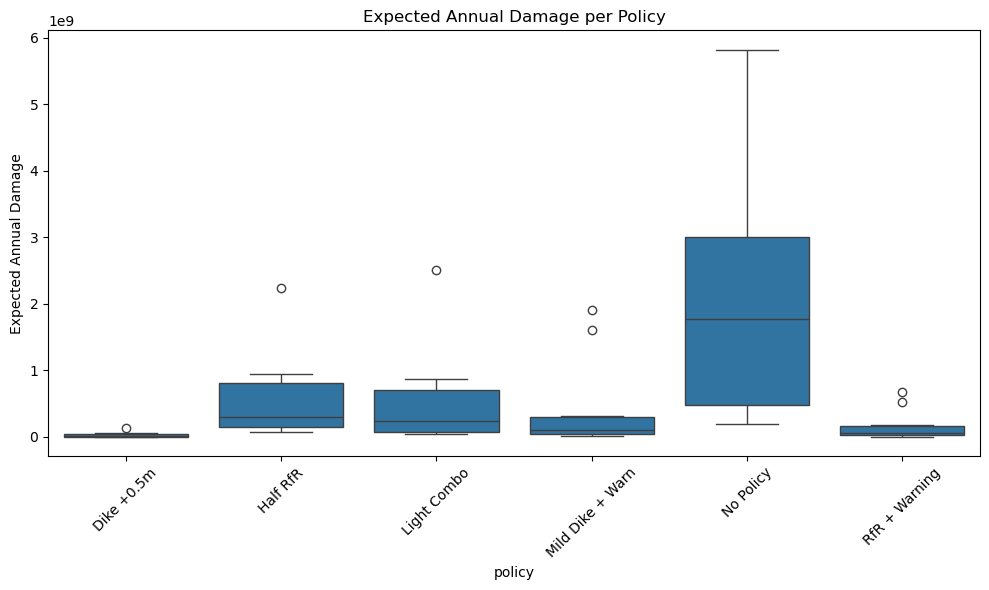

In [35]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# import pandas as pd

# Zet outcomes om naar DataFrame
df_out = pd.DataFrame(outcomes)

# Voeg policy/scenario info toe
df_exp = pd.DataFrame(experiments)
df_results = pd.concat([df_exp, df_out], axis=1)


plt.figure(figsize=(10, 6))
sns.boxplot(x='policy', y='Expected Annual Damage', data=df_results)
plt.title("Expected Annual Damage per Policy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


